In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_csv('loan.csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [9]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [12]:
df.dropna(subset=['Gender'], inplace=True)
df.isnull().sum()

Loan_ID               0
Gender                0
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

<Axes: >

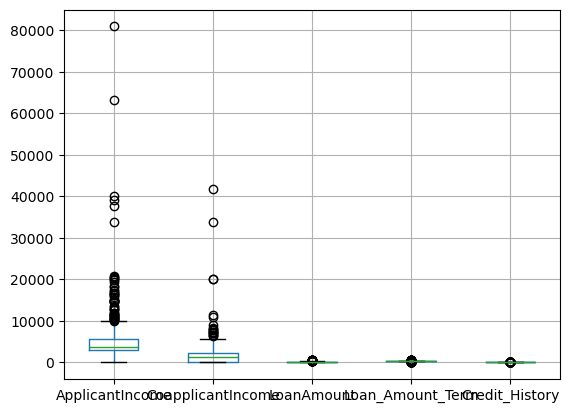

In [14]:
df.boxplot()

In [15]:
df.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,601.000000,601.000000,579.000000,587.000000,552.000000
mean,5296.818636,1624.610516,145.017271,342.010221,0.844203
std,5796.332957,2947.638410,82.565103,65.428333,0.362992
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2882.000000,0.000000,100.000000,360.000000,1.000000
50%,3813.000000,1167.000000,127.000000,360.000000,1.000000
75%,5746.000000,2306.000000,166.500000,360.000000,1.000000
max,81000.000000,41667.000000,650.000000,480.000000,1.000000


In [16]:
def cap_outliers(column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    return df[column].clip(lower_bound, upper_bound)

df['ApplicantIncome']=cap_outliers('ApplicantIncome')
df['CoapplicantIncome']=cap_outliers('CoapplicantIncome')
df['LoanAmount']=cap_outliers('LoanAmount')

In [17]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,601.000000,601.000000,579.000000,587.000000,552.000000
mean,4585.920133,1419.362596,137.430484,342.010221,0.844203
std,2423.677052,1625.675597,57.266745,65.428333,0.362992
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2882.000000,0.000000,100.000000,360.000000,1.000000
50%,3813.000000,1167.000000,127.000000,360.000000,1.000000
75%,5746.000000,2306.000000,166.500000,360.000000,1.000000
max,10042.000000,5765.000000,266.250000,480.000000,1.000000


In [18]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [19]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [20]:
df['Dependents'].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [22]:
df['Dependents'].replace(['0','1','2','3+'], [0,1,2,3], inplace=True)

C:\Users\Pranadh\AppData\Local\Temp\ipykernel_21240\1463276733.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Dependents'].replace(['0','1','2','3+'], [0,1,2,3], inplace=True)


In [23]:
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)


In [24]:
df['Dependents'].isnull().sum()

0

In [25]:
df['Married'].fillna(df['Married'].mode()[0], inplace=True)

C:\Users\Pranadh\AppData\Local\Temp\ipykernel_21240\891759981.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Married'].fillna(df['Married'].mode()[0], inplace=True)


In [26]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [27]:
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

C:\Users\Pranadh\AppData\Local\Temp\ipykernel_21240\3324225749.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)


In [28]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [30]:
df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)

C:\Users\Pranadh\AppData\Local\Temp\ipykernel_21240\1977403596.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)


In [31]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,137.430484,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.000000,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.000000,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.000000,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.000000,360.0,1.0,Urban,Y


In [32]:
df['Loan_Amount_Term'].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [33]:
df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0], inplace=True)

C:\Users\Pranadh\AppData\Local\Temp\ipykernel_21240\4110103852.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0], inplace=True)


In [34]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [37]:
df["Credit_History"].fillna(df["Credit_History"].mode()[0], inplace=True)

C:\Users\Pranadh\AppData\Local\Temp\ipykernel_21240\895604288.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Credit_History"].fillna(df["Credit_History"].mode()[0], inplace=True)


In [38]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [39]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,137.430484,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.000000,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.000000,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.000000,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.000000,360.0,1.0,Urban,Y


In [42]:
df.drop(columns=['Loan_ID'] ,axis=1, inplace=True)

In [44]:
df['Gender'].replace(['Male','Female'], [0,1], inplace=True)
df['Married'].replace(['No','Yes'], [0,1], inplace=True)
df['Education'].replace(['Graduate','Not Graduate'], [0,1], inplace=True)
df['Self_Employed'].replace(['No','Yes'], [0,1], inplace=True)


C:\Users\Pranadh\AppData\Local\Temp\ipykernel_21240\1920681066.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'].replace(['Male','Female'], [0,1], inplace=True)
C:\Users\Pranadh\AppData\Local\Temp\ipykernel_21240\1920681066.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Marri

In [46]:
df=pd.get_dummies(df, columns=['Property_Area'])

In [47]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0,0,0.0,0,0,5849,0.0,137.430484,360.0,1.0,Y,False,False,True
1,0,1,1.0,0,0,4583,1508.0,128.000000,360.0,1.0,N,True,False,False
2,0,1,0.0,0,1,3000,0.0,66.000000,360.0,1.0,Y,False,False,True
3,0,1,0.0,1,0,2583,2358.0,120.000000,360.0,1.0,Y,False,False,True
4,0,0,0.0,0,0,6000,0.0,141.000000,360.0,1.0,Y,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,1,0,0.0,0,0,2900,0.0,71.000000,360.0,1.0,Y,True,False,False
610,0,1,3.0,0,0,4106,0.0,40.000000,180.0,1.0,Y,True,False,False
611,0,1,1.0,0,0,8072,240.0,253.000000,360.0,1.0,Y,False,False,True
612,0,1,2.0,0,0,7583,0.0,187.000000,360.0,1.0,Y,False,False,True


In [48]:
df["Loan_Status"].replace(['Y','N'], [1,0], inplace=True)
df["Property_Area_Rural"].replace([True,False], [1,0], inplace=True)
df['Property_Area_Semiurban'].replace([True,False], [1,0], inplace=True)
df['Property_Area_Urban'].replace([True,False], [1,0], inplace=True)

C:\Users\Pranadh\AppData\Local\Temp\ipykernel_21240\2799798188.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Loan_Status"].replace(['Y','N'], [1,0], inplace=True)
C:\Users\Pranadh\AppData\Local\Temp\ipykernel_21240\2799798188.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Loan_Sta

In [49]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0,0,0.0,0,0,5849,0.0,137.430484,360.0,1.0,1,0,0,1
1,0,1,1.0,0,0,4583,1508.0,128.000000,360.0,1.0,0,1,0,0
2,0,1,0.0,0,1,3000,0.0,66.000000,360.0,1.0,1,0,0,1
3,0,1,0.0,1,0,2583,2358.0,120.000000,360.0,1.0,1,0,0,1
4,0,0,0.0,0,0,6000,0.0,141.000000,360.0,1.0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,1,0,0.0,0,0,2900,0.0,71.000000,360.0,1.0,1,1,0,0
610,0,1,3.0,0,0,4106,0.0,40.000000,180.0,1.0,1,1,0,0
611,0,1,1.0,0,0,8072,240.0,253.000000,360.0,1.0,1,0,0,1
612,0,1,2.0,0,0,7583,0.0,187.000000,360.0,1.0,1,0,0,1


In [50]:
x=df.drop(columns=['Loan_Status'])
y=df['Loan_Status']

In [51]:
from sklearn.model_selection import train_test_split    
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [65]:
from sklearn.svm import SVC
model=SVC(kernel='linear',C=5.0,gamma='scale',degree=3)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test,y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))



Accuracy: 0.8760330578512396
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.48      0.65        29
           1       0.86      1.00      0.92        92

    accuracy                           0.88       121
   macro avg       0.93      0.74      0.79       121
weighted avg       0.89      0.88      0.86       121

Confusion Matrix:
 [[14 15]
 [ 0 92]]
